# Task - 1 Problem Definition and Dataset Exploration

### Q1: What is the problem statement?

**Ans:** We want to predict if a person has heart disease or not using their health data like age, blood pressure, weight, etc.

### Q2: Load and explore the dataset

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv("/Users/rutvamavani/Desktop/ML Project 2/cardio_train.csv" , sep=";")
print("Data Loaded!")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")

Data Loaded!
Total Rows: 70000
Total Columns: 13


### Q3: Show first 5 rows

In [4]:
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


### Q4: What are the columns and their meanings?

**Ans:**
- **id** = Patient ID
- **age** = Age in days
- **gender** = 1=Female, 2=Male
- **height** = Height in cm
- **weight** = Weight in kg
- **ap_hi** = Upper blood pressure
- **ap_lo** = Lower blood pressure
- **cholesterol** = 1=Normal, 2=High, 3=Very High
- **gluc** = Glucose: 1=Normal, 2=High, 3=Very High
- **smoke** = 0=No, 1=Yes
- **alco** = Alcohol: 0=No, 1=Yes
- **active** = Exercise: 0=No, 1=Yes
- **cardio** = Heart Disease: 0=No, 1=Yes (Target)

### Q5: Show data types

In [8]:
df.dtypes

id               int64
age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object

### Q6: Show statistics summary

In [11]:
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


### Q7: Initial observations

In [14]:
print(f"Total records: {len(df)}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")
print("\nTarget distribution:")
print(df['cardio'].value_counts())

Total records: 70000
Missing values: 0
Duplicates: 0

Target distribution:
cardio
0    35021
1    34979
Name: count, dtype: int64


# Tak - 2 Data Cleaning and Pre-processing

### Q1: Check missing values

In [18]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64


### Q2: Convert age from days to years

In [21]:
df['age'] = (df['age'] / 365).astype(int)
print(f"Age range: {df['age'].min()} to {df['age'].max()} years")

Age range: 29 to 64 years


### Q3: What are outliers and how to handle them?

**Ans:** Outliers are unusual values that don't fit with other data. Example: BP = 16000 (impossible!). We remove them by keeping only realistic values.

In [24]:
# Remove wrong BP values
print("Before:", len(df))
df = df[(df['ap_hi'] >= 80) & (df['ap_hi'] <= 250)]
df = df[(df['ap_lo'] >= 40) & (df['ap_lo'] <= 200)]
df = df[df['ap_hi'] > df['ap_lo']]
print("After:", len(df))

Before: 70000
After: 68667


### Q4: Remove outliers from height and weight

In [27]:
df = df[(df['height'] >= 100) & (df['height'] <= 220)]
df = df[(df['weight'] >= 30) & (df['weight'] <= 200)]
print(f"Records after cleaning: {len(df)}")

Records after cleaning: 68634


### Q5: Create BMI feature

**Ans:** BMI = Weight / (Height in meters)²

In [30]:
df['bmi'] = df['weight'] / ((df['height'] / 100) ** 2)
print(f"BMI range: {df['bmi'].min():.1f} to {df['bmi'].max():.1f}")

BMI range: 10.7 to 152.6


### Q6: Drop ID column (not needed)

In [33]:
df = df.drop('id', axis=1)
print("Columns:", list(df.columns))

Columns: ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'bmi']


### Q7: EDA - Show target distribution

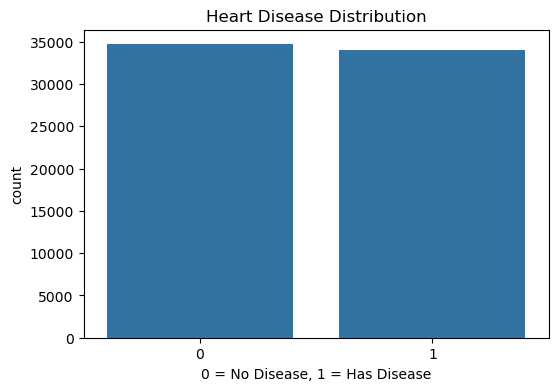

In [36]:
plt.figure(figsize=(6, 4))
sns.countplot(x='cardio', data=df)
plt.title('Heart Disease Distribution')
plt.xlabel('0 = No Disease, 1 = Has Disease')
plt.show()

### Q8: Show correlation heatmap

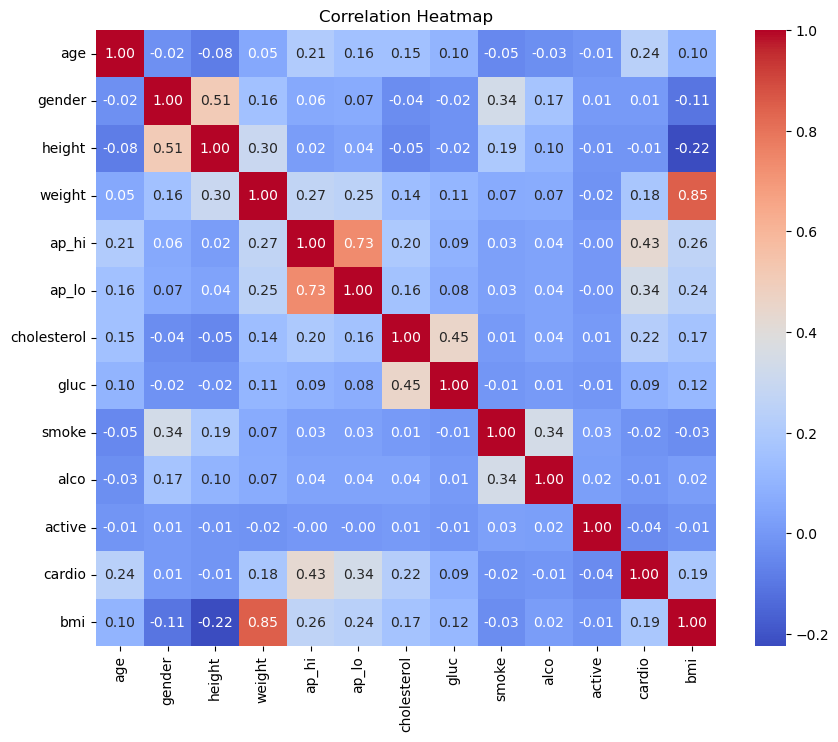

In [39]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

### Q9: What is normalization?

**Ans:** Normalization means converting all values to same scale (usually 0-1 or -1 to 1). This helps model learn better.

In [42]:
from sklearn.preprocessing import StandardScaler

# Split features and target
X = df.drop('cardio', axis=1)
y = df['cardio']

# Scale numerical columns
scaler = StandardScaler()
num_cols = ['age', 'height', 'weight', 'ap_hi', 'ap_lo', 'bmi']
X[num_cols] = scaler.fit_transform(X[num_cols])
print("Scaling done!")

Scaling done!


### Q10: Split data into train and test

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {len(X_train)}, Test: {len(X_test)}")

Train: 54907, Test: 13727


---
# Task - 3: Model Creation

### Q1: Which algorithms can we use?

**Ans:** For this yes/no prediction, we can use:
1. Logistic Regression (simple and fast)
2. Decision Tree (easy to understand)
3. Random Forest (better accuracy)
4. SVM (good for complex data)
5. KNN (uses nearby points)

### Q2: Train Logistic Regression (using library)

In [50]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
print("Logistic Regression trained!")

Logistic Regression trained!


### Q3: Train Random Forest (using library)

In [53]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
print("Random Forest trained!")

Random Forest trained!


### Q4: Implement Logistic Regression WITHOUT library (from scratch)

**Ans:** We create our own class that uses math formulas to predict.

In [55]:
class MyLogisticRegression:
    def __init__(self, lr=0.01, iterations=1000):
        self.lr = lr  # learning rate
        self.iterations = iterations
        self.weights = None
        self.bias = None
    
    def sigmoid(self, z):
        # Converts any number to 0-1 range
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))
    
    def fit(self, X, y):
        # Initialize weights
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        X = np.array(X)
        y = np.array(y)
        
        # Train loop
        for _ in range(self.iterations):
            # Calculate predictions
            linear = np.dot(X, self.weights) + self.bias
            pred = self.sigmoid(linear)
            
            # Update weights (gradient descent)
            dw = (1/n_samples) * np.dot(X.T, (pred - y))
            db = (1/n_samples) * np.sum(pred - y)
            
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
    
    def predict(self, X):
        linear = np.dot(np.array(X), self.weights) + self.bias
        pred = self.sigmoid(linear)
        return [1 if p > 0.5 else 0 for p in pred]

# Train our model
my_model = MyLogisticRegression(lr=0.1, iterations=1000)
my_model.fit(X_train, y_train)
my_pred = my_model.predict(X_test)
print("Custom model trained!")

Custom model trained!


# Task - 4: Model Evaluation

### Q1: What are evaluation metrics?

**Ans:**
- **Accuracy** = How many predictions are correct overall
- **Precision** = Of all "Yes" predictions, how many are actually correct
- **Recall** = Of all actual "Yes" cases, how many did we find
- **F1-Score** = Balance between Precision and Recall

### Q2: Evaluate Logistic Regression

In [59]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("=== Logistic Regression ===")
print(f"Accuracy:  {accuracy_score(y_test, lr_pred):.2%}")
print(f"Precision: {precision_score(y_test, lr_pred):.2%}")
print(f"Recall:    {recall_score(y_test, lr_pred):.2%}")
print(f"F1-Score:  {f1_score(y_test, lr_pred):.2%}")

=== Logistic Regression ===
Accuracy:  73.18%
Precision: 75.61%
Recall:    66.80%
F1-Score:  70.93%


### Q3: Evaluate Random Forest

In [62]:
print("=== Random Forest ===")
print(f"Accuracy:  {accuracy_score(y_test, rf_pred):.2%}")
print(f"Precision: {precision_score(y_test, rf_pred):.2%}")
print(f"Recall:    {recall_score(y_test, rf_pred):.2%}")
print(f"F1-Score:  {f1_score(y_test, rf_pred):.2%}")

=== Random Forest ===
Accuracy:  70.92%
Precision: 70.48%
Recall:    69.94%
F1-Score:  70.21%


### Q4: Evaluate Custom Model

In [67]:
print("=== Custom Logistic Regression ===")
print(f"Accuracy:  {accuracy_score(y_test, my_pred):.2%}")
print(f"Precision: {precision_score(y_test, my_pred):.2%}")
print(f"Recall:    {recall_score(y_test, my_pred):.2%}")
print(f"F1-Score:  {f1_score(y_test, my_pred):.2%}")

=== Custom Logistic Regression ===
Accuracy:  73.11%
Precision: 75.48%
Recall:    66.83%
F1-Score:  70.89%


### Q5: What is Confusion Matrix?

**Ans:** A table showing:
- True Positive (TP) = Correctly predicted "Yes"
- True Negative (TN) = Correctly predicted "No"
- False Positive (FP) = Wrongly predicted "Yes"
- False Negative (FN) = Wrongly predicted "No"

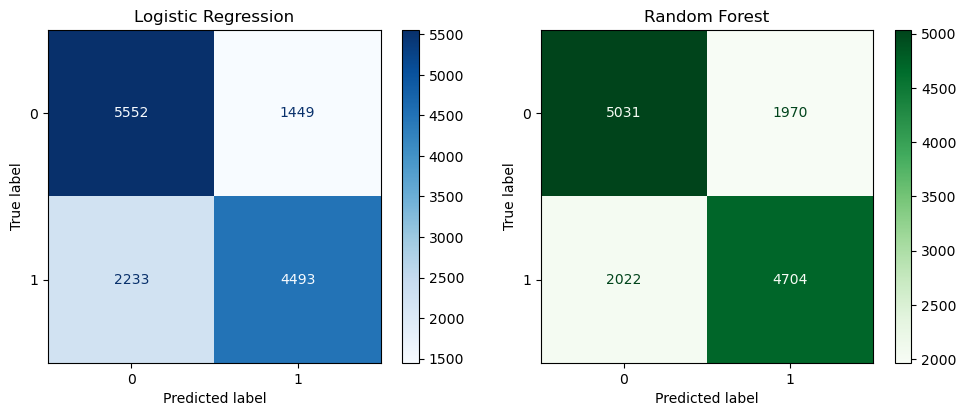

In [70]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay.from_predictions(y_test, lr_pred, ax=axes[0], cmap='Blues')
axes[0].set_title('Logistic Regression')

ConfusionMatrixDisplay.from_predictions(y_test, rf_pred, ax=axes[1], cmap='Greens')
axes[1].set_title('Random Forest')

plt.tight_layout()
plt.show()

### Q6: What is Overfitting and Underfitting?

**Ans:**
- **Overfitting** = Model memorizes training data, fails on new data (train acc >> test acc)
- **Underfitting** = Model is too simple, fails on both (both acc are low)

In [73]:
print("=== Checking Overfitting ===")
print("\nLogistic Regression:")
print(f"  Train Accuracy: {lr_model.score(X_train, y_train):.2%}")
print(f"  Test Accuracy:  {lr_model.score(X_test, y_test):.2%}")

print("\nRandom Forest:")
print(f"  Train Accuracy: {rf_model.score(X_train, y_train):.2%}")
print(f"  Test Accuracy:  {rf_model.score(X_test, y_test):.2%}")

=== Checking Overfitting ===

Logistic Regression:
  Train Accuracy: 72.64%
  Test Accuracy:  73.18%

Random Forest:
  Train Accuracy: 98.06%
  Test Accuracy:  70.92%


# Task - 5: Advanced Model Training

### Q1: What is Cross-Validation?

**Ans:** Instead of one train-test split, we test on different parts of data multiple times. This gives more reliable results.

In [77]:
from sklearn.model_selection import cross_val_score

# 5-fold cross-validation
lr_scores = cross_val_score(LogisticRegression(max_iter=1000), X, y, cv=5)
print("Logistic Regression CV:")
print(f"  Scores: {lr_scores}")
print(f"  Average: {lr_scores.mean():.2%}")

rf_scores = cross_val_score(RandomForestClassifier(n_estimators=100, random_state=42), X, y, cv=5)
print("\nRandom Forest CV:")
print(f"  Scores: {rf_scores}")
print(f"  Average: {rf_scores.mean():.2%}")

Logistic Regression CV:
  Scores: [0.72339186 0.73074962 0.72703431 0.72987543 0.7241731 ]
  Average: 72.70%

Random Forest CV:
  Scores: [0.70772929 0.71355722 0.7112989  0.70925912 0.70304532]
  Average: 70.90%


### Q2: Compare multiple models

In [79]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN': KNeighborsClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

print("=== Model Comparison ===")
results = []
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5)
    results.append({'Model': name, 'Score': scores.mean()})
    print(f"{name}: {scores.mean():.2%}")

results_df = pd.DataFrame(results).sort_values('Score', ascending=False)
print("\nBest Model:", results_df.iloc[0]['Model'])

=== Model Comparison ===
Logistic Regression: 72.70%
Decision Tree: 63.62%
Random Forest: 70.90%
KNN: 69.59%
Gradient Boosting: 73.44%

Best Model: Gradient Boosting


### Q3: What is Hyperparameter Tuning?

**Ans:** Finding the best settings for a model. Like adjusting volume and bass on a speaker to get best sound.

In [81]:
from sklearn.model_selection import GridSearchCV

# Try different settings for Random Forest
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, 15]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3)
grid.fit(X_train, y_train)

print("Best Settings:", grid.best_params_)
print(f"Best Score: {grid.best_score_:.2%}")

Best Settings: {'max_depth': 10, 'n_estimators': 100}
Best Score: 73.26%


### Q4: Train best model

In [85]:
best_model = grid.best_estimator_
best_pred = best_model.predict(X_test)

print("=== Best Model Results ===")
print(f"Accuracy:  {accuracy_score(y_test, best_pred):.2%}")
print(f"F1-Score:  {f1_score(y_test, best_pred):.2%}")

=== Best Model Results ===
Accuracy:  73.91%
F1-Score:  71.79%


# Task - 6: Visualization of Metrics and Graphs

### Q1: Show model comparison chart

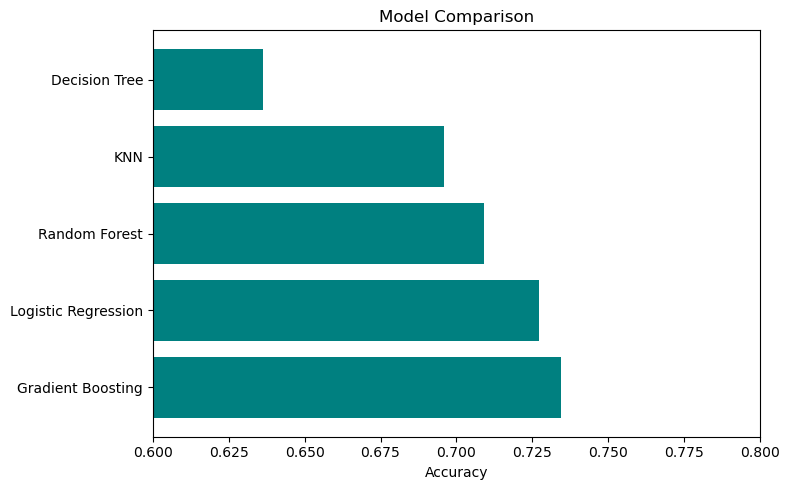

In [89]:
plt.figure(figsize=(8, 5))
plt.barh(results_df['Model'], results_df['Score'], color='teal')
plt.xlabel('Accuracy')
plt.title('Model Comparison')
plt.xlim(0.6, 0.8)
plt.tight_layout()
plt.show()

### Q2: What is ROC Curve?

**Ans:** ROC curve shows how well model separates classes. AUC (Area Under Curve) closer to 1 = better model.

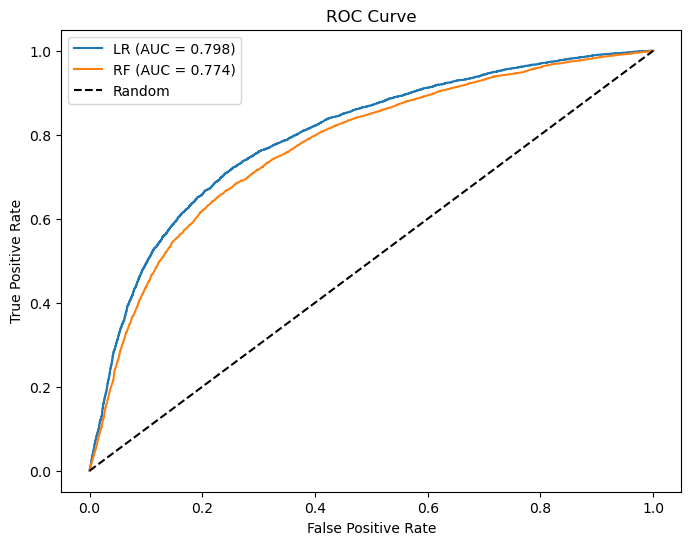

In [92]:
from sklearn.metrics import roc_curve, auc

# Get probabilities
lr_prob = lr_model.predict_proba(X_test)[:, 1]
rf_prob = rf_model.predict_proba(X_test)[:, 1]

plt.figure(figsize=(8, 6))

# Logistic Regression
fpr, tpr, _ = roc_curve(y_test, lr_prob)
plt.plot(fpr, tpr, label=f'LR (AUC = {auc(fpr, tpr):.3f})')

# Random Forest
fpr, tpr, _ = roc_curve(y_test, rf_prob)
plt.plot(fpr, tpr, label=f'RF (AUC = {auc(fpr, tpr):.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

### Q3: Show Feature Importance

**Ans:** Which features (columns) are most important for prediction.

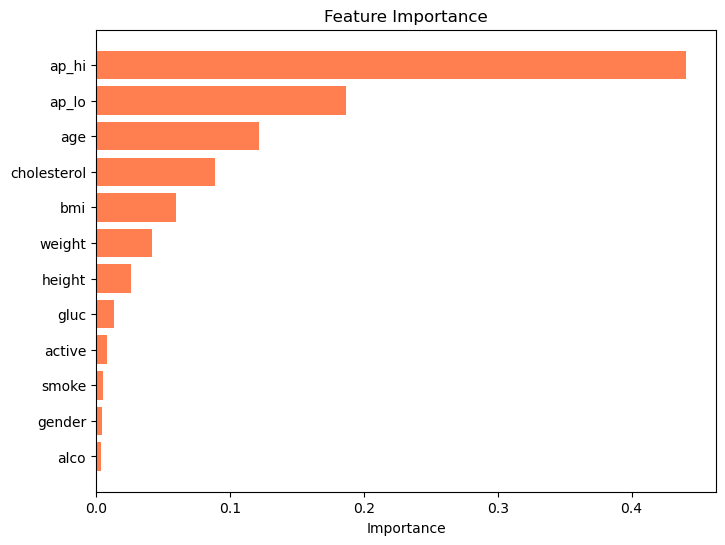

In [95]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(importance['Feature'], importance['Importance'], color='coral')
plt.xlabel('Importance')
plt.title('Feature Importance')
plt.show()

### Q4: Summary of all metrics

In [98]:
from sklearn.metrics import roc_auc_score

summary = pd.DataFrame([
    {
        'Model': 'Logistic Regression',
        'Accuracy': f"{accuracy_score(y_test, lr_pred):.2%}",
        'Precision': f"{precision_score(y_test, lr_pred):.2%}",
        'Recall': f"{recall_score(y_test, lr_pred):.2%}",
        'F1-Score': f"{f1_score(y_test, lr_pred):.2%}"
    },
    {
        'Model': 'Random Forest',
        'Accuracy': f"{accuracy_score(y_test, rf_pred):.2%}",
        'Precision': f"{precision_score(y_test, rf_pred):.2%}",
        'Recall': f"{recall_score(y_test, rf_pred):.2%}",
        'F1-Score': f"{f1_score(y_test, rf_pred):.2%}"
    },
    {
        'Model': 'Best Model (Tuned)',
        'Accuracy': f"{accuracy_score(y_test, best_pred):.2%}",
        'Precision': f"{precision_score(y_test, best_pred):.2%}",
        'Recall': f"{recall_score(y_test, best_pred):.2%}",
        'F1-Score': f"{f1_score(y_test, best_pred):.2%}"
    }
])

print("=== Final Summary ===")
print(summary.to_string(index=False))

=== Final Summary ===
              Model Accuracy Precision Recall F1-Score
Logistic Regression   73.18%    75.61% 66.80%   70.93%
      Random Forest   70.92%    70.48% 69.94%   70.21%
 Best Model (Tuned)   73.91%    76.32% 67.77%   71.79%


---
# 🌐 LAB 7: Flask Project Setup

### Q1: What is Flask?

**Ans:** Flask is a simple Python web framework. We use it to create a website where users can input data and get predictions.

### Q2: Save the model for Flask

In [103]:
import pickle

# Save model
with open('cardio_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Save scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Model saved: cardio_model.pkl")
print("Scaler saved: scaler.pkl")

Model saved: cardio_model.pkl
Scaler saved: scaler.pkl


### Q3: Flask project structure

**Ans:**
```
project/
├── app.py              # Main code
├── cardio_model.pkl    # Saved model
├── scaler.pkl          # Saved scaler
├── templates/          # HTML files
│   ├── index.html      # Form page
│   └── result.html     # Result page
└── static/             # CSS files
    └── style.css
```

### Q4: Simple Flask app code

In [ ]:
flask_code = '''
# app.py
from flask import Flask, render_template, request
import pickle
import numpy as np

app = Flask(__name__)

# Load model
model = pickle.load(open('cardio_model.pkl', 'rb'))
scaler = pickle.load(open('scaler.pkl', 'rb'))

@app.route('/')
def home():
    return render_template('index.html')

@app.route('/predict', methods=['POST'])
def predict():
    # Get form data
    data = [float(x) for x in request.form.values()]
    
    # Predict
    prediction = model.predict([data])[0]
    result = "High Risk" if prediction == 1 else "Low Risk"
    
    return render_template('result.html', prediction=result)

if __name__ == '__main__':
    app.run(debug=True)
'''
print(flask_code)

### Q5: HTML form template (index.html)

In [ ]:
html_code = '''
<!DOCTYPE html>
<html>
<head>
    <title>Heart Disease Prediction</title>
</head>
<body>
    <h1>Heart Disease Prediction</h1>
    <form action="/predict" method="POST">
        Age: <input type="number" name="age"><br>
        Gender (1=F, 2=M): <input type="number" name="gender"><br>
        Height (cm): <input type="number" name="height"><br>
        Weight (kg): <input type="number" name="weight"><br>
        Systolic BP: <input type="number" name="ap_hi"><br>
        Diastolic BP: <input type="number" name="ap_lo"><br>
        Cholesterol (1-3): <input type="number" name="cholesterol"><br>
        Glucose (1-3): <input type="number" name="gluc"><br>
        Smoke (0/1): <input type="number" name="smoke"><br>
        Alcohol (0/1): <input type="number" name="alco"><br>
        Active (0/1): <input type="number" name="active"><br>
        <button type="submit">Predict</button>
    </form>
</body>
</html>
'''
print(html_code)

### Q6: How to run Flask app?

**Ans:**
1. Install Flask: `pip install flask`
2. Run: `python app.py`
3. Open browser: `http://127.0.0.1:5000`